## Submission 2. Bias

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from scipy import stats
import starbars

cmap = mpl.colormaps['cool']

In [3]:
from spyglass.shijiegu.behavior import get_transition_matrix_animal, return_neighbor_nonneighor
from spyglass.shijiegu.changeOfMind_byTransition import find_COM_transitions, info2matrix

from spyglass.shijiegu.Analysis_SGU import ChangeofMind
from spyglass.common.common_position import IntervalPositionInfo, RawPosition, IntervalLinearizedPosition

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

In [4]:
list_of_days_animals = {}
seq_animals = {}

animal = "molly"
list_of_days_animals[animal]  = ['20220415','20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109','20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']
seq_animals[animal] = 'rev2'

In [5]:
### Run this for data export to Dandi purpose only.
import os
import datajoint as dj

from spyglass.common.common_usage import Export, ExportSelection
paper_key = {"paper_id": "Gu2026"}

ExportSelection().start_export(**paper_key, analysis_id="change_of_mind_bias")

[11:12:12][INFO] Spyglass: Starting {'export_id': 100}
INFO:spyglass:Starting {'export_id': 100}


### Bias

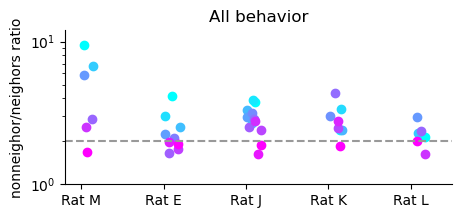

In [6]:
fig, axes = plt.subplots(1, 1, figsize=(5, 2),sharey = True)

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]
for animal in animals:

    days = list_of_days_animals[animal]
    T = get_transition_matrix_animal(animal, animal, list_of_days_animals[animal])
    P_behavior = np.stack([T[d] for d in T], axis = 2)
    P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior) 
    #actually they are same-side vs switch-side

    norm = Normalize(vmin=0, vmax=len(days)-1)
    
    for ind in np.arange(len(days)):
        ratio = P_nonneighors[ind]/P_neighors[ind]
        x_shift = np.random.rand(1)/5
        axes.scatter(np.zeros_like(ratio) + animal_ind + x_shift, ratio, color = cmap(norm(ind)))

    animal_ind += 1

# log scale
axes.set_yscale('log')

#axes.axhline(y = 1, color=[0.6,0.6,0.6], linestyle='--')
axes.axhline(y = 2, color=[0.6,0.6,0.6], linestyle='--')
axes.set_xticks(np.arange(len(animals)));
axes.set_xticklabels(["Rat " + animal[0].upper() for animal in animals]);
axes.set_xlim([-0.2,len(animals)-0.5]);
axes.set_ylim([1,12]);
axes.set_title("All behavior")
axes.set_ylabel("nonneighor/neighors ratio")
axes.spines[['right', 'top']].set_visible(False)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1/figure1_bias.pdf"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png",bbox_inches='tight')

### Stats for bias

In [5]:
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}
import statsmodels.api as sm
import numpy.matlib as ml
import matplotlib.patheffects as PathEffects

pvalue 0.0003978606788195885
pvalue 0.003809457955633741
pvalue 0.0004389655778683597
pvalue 0.5380101463115221
pvalue 0.39596017347085566


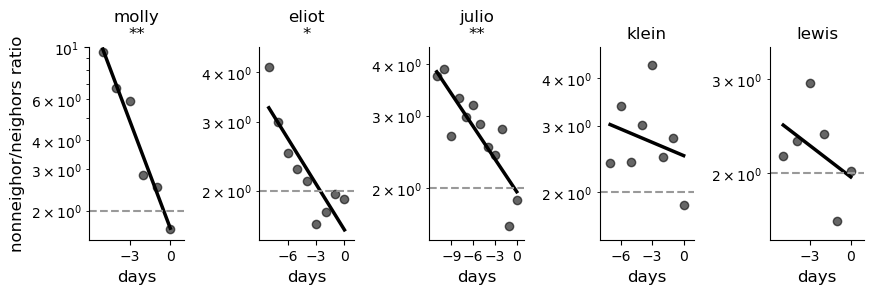

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]
results_all = []
for animal in animals:

    days = list_of_days_animals[animal]
    T = get_transition_matrix_animal(animal, animal, list_of_days_animals[animal])
    P_behavior = np.stack([T[d] for d in T], axis = 2)
    P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)

    norm = Normalize(vmin=0, vmax=len(days)-1)

    ratios = [P_nonneighors[ind]/P_neighors[ind] for ind in np.arange(len(days))]
        
    x_indeces = np.arange(len(days))
    axes[animal_ind].scatter(x_indeces - x_indeces[-1], ratios, color = "k",
                 label = f"Rat {animal[0].upper()}", alpha = 0.6)
    #axes.plot(x_indeces - x_indeces[-1], ratios, color = color_by_rat[animal.lower()[:5]])
    X = sm.add_constant(x_indeces)

    # 3. Create and fit the OLS (Ordinary Least Squares) model
    model = sm.OLS(np.log(ratios), X)
    results = model.fit()

    results_all.append(results)

    X_pred = np.linspace(x_indeces[0],x_indeces[-1],20)
    X_pred = sm.add_constant(X_pred)
    X_plot = X_pred[:,-1] - x_indeces[-1]
    Y_pred = np.exp(results.predict(X_pred))
    axes[animal_ind].plot(X_plot, Y_pred, color="k", linewidth = 2.5) #color_by_rat[animal.lower()[:5]]
    pvalue = results.pvalues[1]
    print("pvalue",pvalue)
    mid_ind = int(len(X_plot)/2)
    if pvalue <= 0.001:
        txt = axes[animal_ind].set_title(animal+"\n**")
    elif pvalue <= 0.01:
        txt = axes[animal_ind].set_title(animal+"\n*")
    else:
         axes[animal_ind].set_title(animal)
    #txt.set_path_effects([PathEffects.withStroke(linewidth=5, foreground='w')])


    #### add stats
    # t_statistic, p_value = stats.ttest_rel(P_neighors, P_nonneighors)
    # print("p_value",p_value)
    # axes.text(animal_ind + 0.1,5,str(np.round(p_value, 4)))
    ########

    # log scale
    axes[animal_ind].set_yscale('log')
    
    # legend = axes.legend(edgecolor = 'k',fontsize = 12, loc='upper left',bbox_to_anchor=(1.05, 0.8))
    # # Get the legend frame (which is a Rectangle object)
    # frame = legend.get_frame()
    # # Set the linewidth of the legend frame
    # frame.set_linewidth(1)

    axes[animal_ind].axhline(y = 2, color=[0.6,0.6,0.6], linestyle='--')
    # axes[animal_ind].axhline(y = 1.5, color=[0.6,0.6,0.6], linestyle='--')

    xaxis = x_indeces - x_indeces[-1]
    axes[animal_ind].set_xticks(xaxis[::-1][::3]);
    axes[animal_ind].set_xlim([np.min(xaxis)-1,np.max(xaxis) +1])
    #axes.set_xticklabels(["Rat " + animal[0] for animal in animals]);
    #axes.set_xlim([-1,len(animals) + 1]);
    axes[animal_ind].set_ylim([1.5,np.max(ratios) + 0.5]);
    #axes.set_title("All behavior")
    if animal_ind == 0:
        axes[animal_ind].set_ylabel("nonneighor/neighors ratio", fontsize = 12)
    else:
        axes[animal_ind].set_yticks([])
        axes[animal_ind].set_ylabel("")
        
    axes[animal_ind].set_xlabel("days", fontsize = 12)
    axes[animal_ind].spines[['right', 'top']].set_visible(False)
    animal_ind += 1

plt.subplots_adjust(
    wspace=0.8,
    #hspace=0.2
)

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure1/figure1_bias_linear_regression"
plt.savefig(file_path + ".pdf",bbox_inches='tight')
plt.savefig(file_path + ".png")

### Binomial

In [9]:
animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]

ratios_all = []
for animal in animals:

    days = list_of_days_animals[animal]
    T = get_transition_matrix_animal(animal, animal, list_of_days_animals[animal])
    P_behavior = np.stack([T[d] for d in T], axis = 2)
    P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)

    norm = Normalize(vmin=0, vmax=len(days)-1)

    ratios = [P_nonneighors[ind]/P_neighors[ind] for ind in np.arange(len(days))]
    ratios_all.append(ratios[0])
    

In [10]:
from scipy.stats import binomtest

In [11]:
result = binomtest(np.sum(np.array(ratios_all) > 2), n=len(ratios_all), p=0.5, alternative='greater')
print(result.pvalue)


0.03125


In [12]:
ExportSelection().stop_export(**paper_key, analysis_id="change_of_mind_bias")

### More stats for bias: Mixed linear model

In [26]:
GLM_x = []
GLM_y = []

animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]
for animal in animals:

    days = list_of_days_animals[animal]
    T = get_transition_matrix_animal(animal, animal, list_of_days_animals[animal])
    P_behavior = np.stack([T[d] for d in T], axis = 2)
    P_neighors, P_nonneighors = return_neighbor_nonneighor(P_behavior)

    norm = Normalize(vmin=0, vmax=len(days)-1)

    ratios = [P_nonneighors[ind]/P_neighors[ind] for ind in np.arange(len(days))]
        
    x_indeces = np.arange(len(days))

    animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
    X = x_indeces #- x_indeces[-1]
    X = X.reshape((-1,1))

    Y = np.array(ratios).reshape((-1,1))

    X_animal_category = ml.repmat(animal_category, np.shape(X)[0], 1)
    X = np.hstack((X_animal_category, X))
    GLM_x.append(X)
    GLM_y.append(Y)

GLM_x = np.vstack(GLM_x)
GLM_y = np.vstack(GLM_y)

In [27]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["day"] = GLM_x[:,len(animals)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = np.log(GLM_y)

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(np.log(y),X)
ols_result1 = ols_model.fit()
print("p value of days:",ols_result1.pvalues[-1])

print("Mixed Linear Effect \n",ols_result1.summary())

p value of days: 4.110406455733087e-06
Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.568
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     9.186
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.18e-05
Time:                        08:44:18   Log-Likelihood:                0.98016
No. Observations:                  41   AIC:                             10.04
Df Residuals:                      35   BIC:                             20.32
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [28]:
np.exp(-0.0833)

0.920075083287619